In [9]:
import io
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision import models

In [3]:
from google.colab import drive
drive.mount('/content/drive')
shared_folder = "Machine_learning_project/Data/Raw"

target_df = pd.read_csv(f"/content/drive/MyDrive/{shared_folder}/target.csv")
feature_df = pd.read_csv(f"/content//drive/MyDrive/Machine_learning_project/Data/Processed/listings_image_availability.csv")
test_ids = np.load(f"/content/drive/MyDrive/{shared_folder}/test_ids.npy")
train_ids = np.load(f"/content/drive/MyDrive/{shared_folder}/train_ids.npy")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 78.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=d0f2bf2a91cf14e2ebb5bb6061874c0e232350fdb7e43e91bc90f7daa700de84
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [10]:
class ResNet50Regressor(nn.Module):
    def __init__(self, pretrained: bool = True, freeze_backbone: bool = True):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        backbone = models.resnet50(weights=weights)

        # strip the original classification head
        in_features = backbone.fc.in_features          # 2048 for ResNet-50
        backbone.fc = nn.Identity()                    # strip the classifier
        self.backbone = backbone

        if freeze_backbone:
            # Freeze everything except the last residual block (layer4).
            # Cuts the backward-pass cost a lot while still letting the model
            # adapt its highest-level features to this task.
            for name, param in self.backbone.named_parameters():
                if not name.startswith("layer4"):
                    param.requires_grad = False

        # Regression head: 2048 -> 256 -> 1
        self.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)            # (B, 2048)
        return self.head(features).squeeze(1)  # (B,)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [13]:
model = ResNet50Regressor(pretrained=False, freeze_backbone=True).to(device)
ckpt = torch.load("/content/checkpoint.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [ ]:
model.to(device).eval()
# Target conv layer for Grad-CAM
#    ( the last conv layer, right before global pooling)
target_layer = model.backbone.layer4[-1]

In [ ]:
# Machinery to capture activations + gradients

activations = {}
gradients = {}

def forward_hook(module, inp, out):
    activations["value"] = out.detach()

def backward_hook(module, grad_in, grad_out):
    gradients["value"] = grad_out[0].detach()

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

In [ ]:
#Image loading + preprocessing with the ImageNet values just like with training data

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

def load_image_from_url(url):
    resp = requests.get(url, timeout=10)
    return Image.open(io.BytesIO(resp.content)).convert("RGB")

In [ ]:
# Grad-CAM for a single image

def compute_gradcam(img, target_fn=None):
    """
    img: PIL Image
    target_fn: function(embedding) -> scalar tensor to backprop from.
    """
    x = preprocess(img).unsqueeze(0).to(device)

    model.zero_grad()
    embedding = model(x)

    if target_fn is None:
        target_fn = lambda emb: emb.norm(p=2)

    score = target_fn(embedding)
    score.backward()

    acts = activations["value"][0]      # [C, H, W]
    grads = gradients["value"][0]       # [C, H, W]

    weights = grads.mean(dim=(1, 2))               # GAP over spatial dims -> [C]
    cam = torch.relu((weights[:, None, None] * acts).sum(0))  # [H, W]

    cam = cam.cpu().numpy()
    cam -= cam.min()
    if cam.max() > 0:
        cam /= cam.max()
    cam = np.uint8(255 * cam)
    cam = np.array(Image.fromarray(cam).resize(img.size, Image.BILINEAR))
    return cam

In [ ]:
# Overlay heatmap on the original image

def overlay_heatmap(img, cam, alpha=0.45):
    heatmap = cm.jet(cam / 255.0)[:, :, :3]
    heatmap = np.uint8(255 * heatmap)
    img_np = np.array(img.resize((cam.shape[1], cam.shape[0])))
    return np.uint8(img_np * (1 - alpha) + heatmap * alpha)

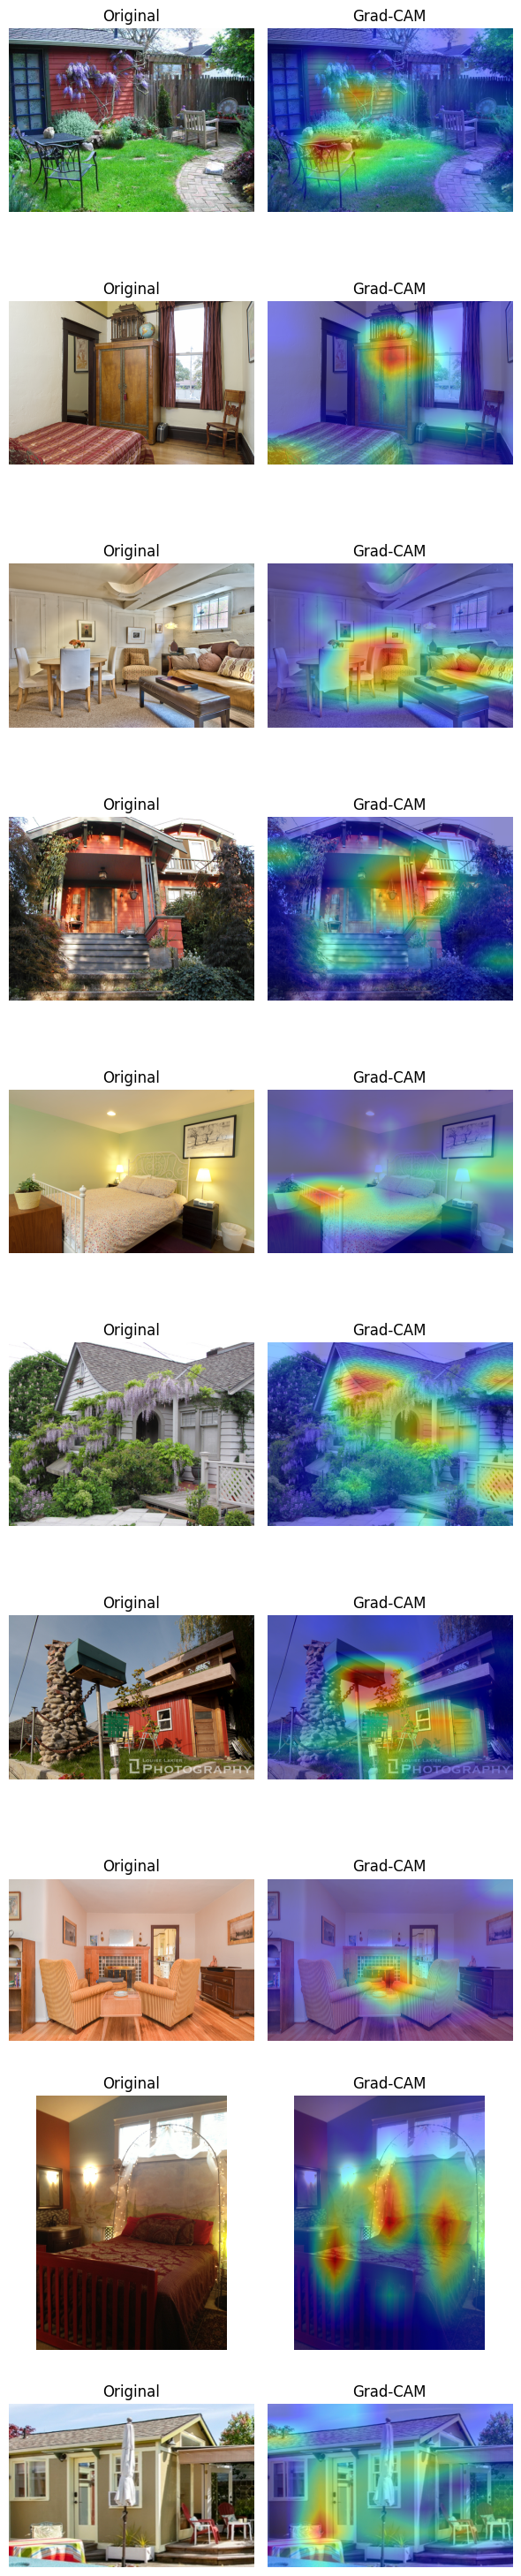

In [14]:
# Run it on 10 images and plot
image_urls = feature_df.loc[feature_df['available'] == True, 'picture_url'].head(10).tolist()

fig, axes = plt.subplots(len(image_urls), 2, figsize=(6, 3 * len(image_urls)))
if len(image_urls) == 1:
    axes = axes[None, :]

for i, url in enumerate(image_urls):
    img = load_image_from_url(url)
    cam = compute_gradcam(img)
    overlay = overlay_heatmap(img, cam)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(overlay)
    axes[i, 1].set_title("Grad-CAM")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()